In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# вычисление значения
# определенного интеграла от
# функции sin(x) на интервале [0,pi/2]
# с помощью метода Монте-Карло

# инициализация генератора случайных чисел
random.seed()

# задание координат
# прямоугольника
X_min = 0
Y_min = 0

X_max = np.pi / 2
Y_max = 1.5

# задание количества членов
# генерируемой случайной
# последовательности
N = 10**4

# инициализация массивов, используемых
# для хранения координат генерируемых
# случайных чисел
x = np.zeros(N)
y = np.zeros(N)

# генерация случайных абсцисс и ординат
for i in range(N):
    x[i] = random.uniform(X_min, X_max)
    y[i] = random.uniform(Y_min, Y_max)


# подсчитываем число точек,
# значения абсцисс которых
# меньше значений функции
# в данной точке
s = 0
for i in range(N):
    if np.sin(x[i]) >= y[i]:
        s = s + 1

# вычисляем площадь прямоугольника
A = (X_max - X_min) * (Y_max - Y_min)
print("Численное значение интеграла: ", A * s / N)
print("Точное значение интеграла: ", 1.0)


Численное значение интеграла:  1.0037388528219389
Точное значение интеграла:  1.0


In [ ]:
# Ячейка № 3

# инициализация генератора случайных чисел
random.seed()

# вычисление значения
# определенного интеграла от
# функции sin(x) на интервале [0,pi/2]
# с помощью метода Монте-Карло
# как среднего значений функции
# вычисленных в точках, координаты которых
# сгенерированы в соответствие с равномерным
# законом распределения
# на интервале [X_min, X_max]

N = 10**4

for i in range(N):
    x[i] = random.uniform(X_min, X_max)

S2 = np.sin(x[:])

print("Численное значение интеграла: ", (X_max - X_min) * np.mean(S2))
print("Точное значение интеграла: ", 1.0)


Численное значение интеграла:  1.0038092963777774
Точное значение интеграла:  1.0


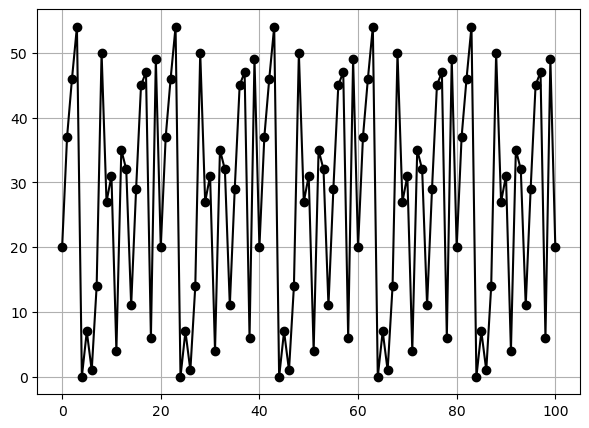

In [4]:
# Ячейка № 4

# программная реализация
# линейного конгруэнтного генератора

# задание параметров генератора
a = 7
c = 7
m = 55

# задание длины случайной последовательности
N = 100

# инициализация массива,
# используемого для хранения
# генерируемой случайной последовательности
x = np.zeros(N + 1)

# задание начального значения последовательности
x[0] = 20

for i in range(N):
    x[i + 1] = (a * x[i] + c) % m

# визуализация случайной последовательности
fig = plt.figure(figsize=(7, 5))
plt.plot(x, color="black", marker="o")
plt.grid(True)

plt.show()

In [5]:
# Ячейка № 5

# задание функции, описывающей
# закон распределения
def P(x):
    z = 1 / (np.sqrt(2 * np.pi * 5)) * np.exp(-(x**2) / 10)

    return z


In [6]:
# Ячейка № 6

# задание функции,
# возвращающей случайное число,
# вычисленное в соответствие
# с алгоритмом Метрополиса
def Metropolis(x, Delta, P):
    # x - координата начальной точки
    # Delta - максимальное значение
    # пробного шага
    # P - функция,  описывающая
    # распределение плотности вероятности

    # алгоритм Метрополиса
    Xt = x + Delta * random.uniform(-1, 1)
    w = P(Xt) / P(x)
    if w >= 1:
        Xnew = Xt
    if w < 1:
        r = random.uniform(0, 1)
        if r <= w:
            Xnew = Xt
        else:
            Xnew = x

    return Xnew


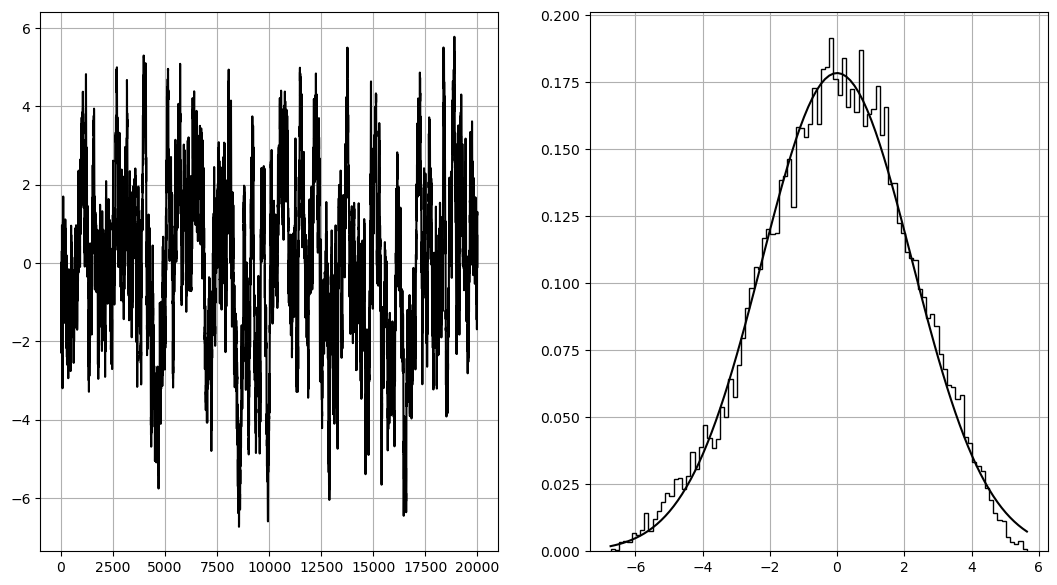

In [7]:
# Ячейка № 7

# инициализация генератора случайных чисел
random.seed()

# задание количества
# генерируемых случайных чисел
N = 2 * 10**4

# инициализация массива,
# используемого для размещения
# генерируемых случайных чисел
x = np.zeros(N)

# задание значения первого члена
# случайной последовательности
x[0] = 0

# генерация случайной последовательности
for i in range(2, N):
    x[i] = Metropolis(x[i - 1], 0.5, P)

# задание значений интервалов гистограммы
N_bin = 100
xbins = np.arange(np.min(x), np.max(x), (max(x) - min(x)) / N_bin)

# визуализация сгенерированной
# случайной последовательности,
# ее гистограммы и плотности
# распределения
fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x, color="black")
# plt.ylim([0, 0.05])
ax.grid(True)

ax = fig.add_subplot(1, 2, 2)
ax.hist(x, bins=xbins, histtype="step", color="black", density=True)
ax.plot(xbins, P(xbins), color="black")
ax.grid(True)

plt.show()